In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Text(0.5, 1.0, 'blurred with 9x9 filter')

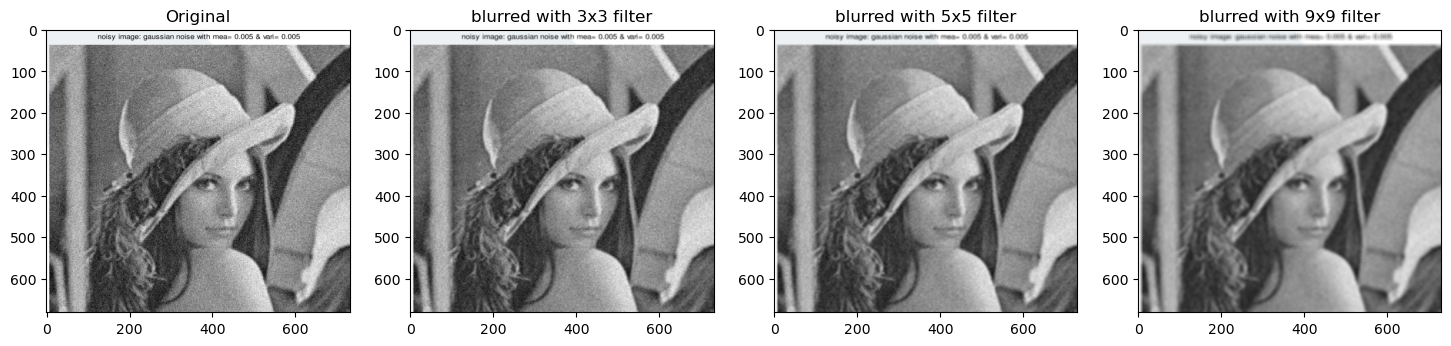

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/Users/230070/Downloads/noisy_image.png')

# Challenge 1: Kernel Size Experiment (Uniform / Box Filter)
kernel_3x3 = np.ones((3, 3), np.float32) / 9
blurred = cv2.filter2D(image, -1, kernel_3x3)

kernel_5x5 = np.ones((5, 5), np.float32) / 25
blurred2 = cv2.filter2D(image, -1, kernel_5x5)

kernel_9x9 = np.ones((9, 9), np.float32) / 81
blurred3 = cv2.filter2D(image, -1, kernel_9x9)

plt.figure(figsize=[18,5])
plt.subplot(141);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(142);plt.imshow(blurred[...,::-1]);plt.title("blurred with 3x3 filter")
plt.subplot(143);plt.imshow(blurred2[...,::-1]);plt.title("blurred with 5x5 filter")
plt.subplot(144);plt.imshow(blurred3[...,::-1]);plt.title("blurred with 9x9 filter")

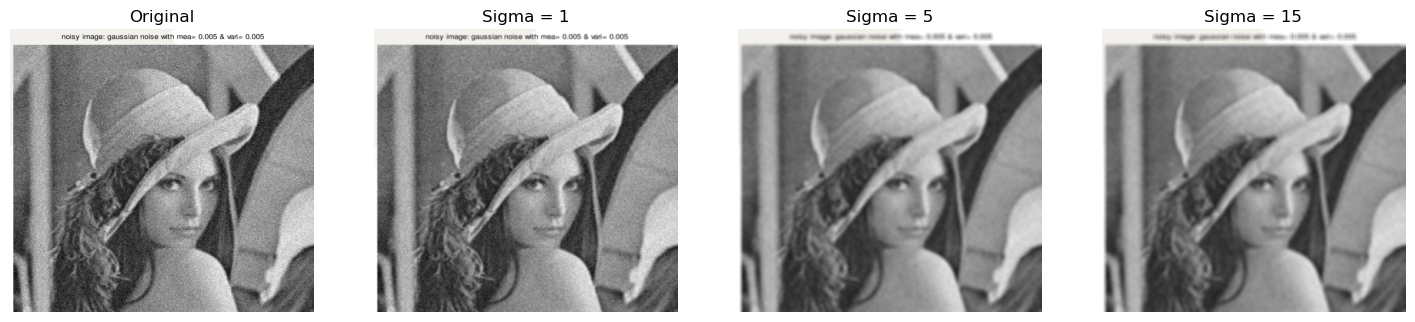

In [8]:
# Challenge 2: Gaussian Sigma Investigation

kernel_size = (11,11)

gauss1 = cv2.GaussianBlur(image, kernel_size, 1)
gauss5 = cv2.GaussianBlur(image, kernel_size, 5)
gauss15 = cv2.GaussianBlur(image, kernel_size, 15)

plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gauss1)
plt.title("Sigma = 1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gauss5)
plt.title("Sigma = 5")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(gauss15)
plt.title("Sigma = 15")
plt.axis("off")

plt.show()

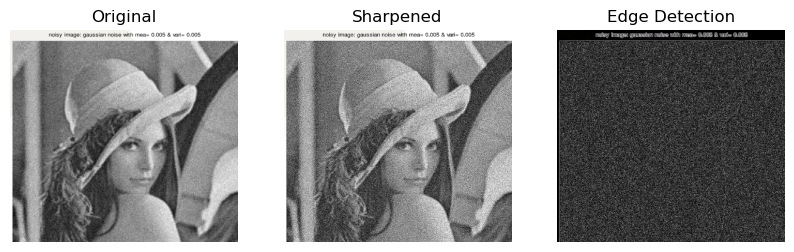

In [10]:
# Challenge 3: Manual Convolution

# sharpening kernel
sharpen_kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
])
sharpened = cv2.filter2D(image, -1, sharpen_kernel)

# edge detection kernel
edge_kernel = np.array([
    [-1,-1,-1],
    [-1,8,-1],
    [-1,-1,-1]
])
edges = cv2.filter2D(image, -1, edge_kernel)



plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sharpened)
plt.title("Sharpened")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges)
plt.title("Edge Detection")
plt.axis("off")

plt.show()

In [12]:
# Challenge 4: Noise Removal Test

gaussian_noise = image + np.random.normal(0,25,image.shape)
gaussian_noise = np.clip(gaussian_noise,0,255).astype(np.uint8)

sp_noise = image.copy()
prob = 0.02

rand = np.random.rand(*image.shape[:2])

sp_noise[rand < prob] = 0
sp_noise[rand > 1-prob] = 255


gaussian_filtered = cv2.GaussianBlur(gaussian_noise,(5,5),1)
uniform_filtered = cv2.blur(gaussian_noise,(5,5))

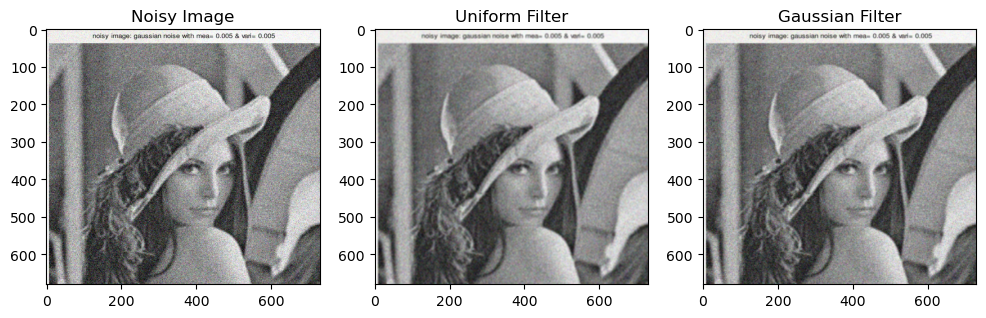

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gaussian_noise)
plt.title("Noisy Image")

plt.subplot(1,3,2)
plt.imshow(uniform_filtered)
plt.title("Uniform Filter")

plt.subplot(1,3,3)
plt.imshow(gaussian_filtered)
plt.title("Gaussian Filter")

plt.show()

In [14]:
# Challenge 5: Edge Preservation Study
box = cv2.blur(image,(7,7))
gaussian = cv2.GaussianBlur(image,(7,7),2)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
gray_box = cv2.cvtColor(box, cv2.COLOR_RGB2GRAY)
gray_gauss = cv2.cvtColor(gaussian, cv2.COLOR_RGB2GRAY)

# Edge intensity difference
diff_box = np.mean(np.abs(gray - gray_box))
diff_gauss = np.mean(np.abs(gray - gray_gauss))

print("Box Filter Difference:", diff_box)
print("Gaussian Filter Difference:", diff_gauss)

Box Filter Difference: 118.80712559585866
Gaussian Filter Difference: 118.45294097559113


In [16]:
import time

In [17]:
# Challenge 6: Performance Comparison
runs = 100

start = time.time()
for i in range(runs):
    cv2.filter2D(image,-1,sharpen_kernel)
filter2d_time = (time.time()-start)/runs

start = time.time()
for i in range(runs):
    cv2.GaussianBlur(image,(5,5),1)
gaussian_time = (time.time()-start)/runs

print("Average filter2D time:", filter2d_time)
print("Average GaussianBlur time:", gaussian_time)

Average filter2D time: 0.0010455822944641113
Average GaussianBlur time: 0.00028451204299926756


In [18]:
# Challenge 7: Kernel Normalization Test
kernel = np.ones((3,3))

bright = cv2.filter2D(image,-1,kernel)

kernel = kernel / kernel.sum()

correct = cv2.filter2D(image,-1,kernel)

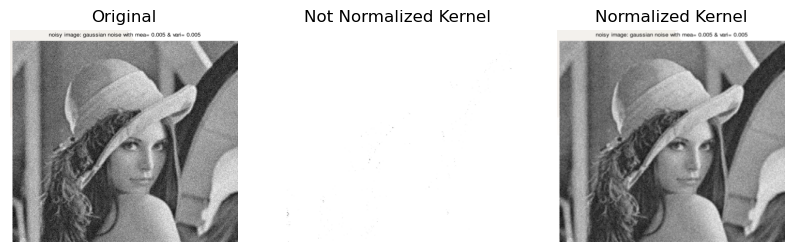

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bright)
plt.title("Not Normalized Kernel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(correct)
plt.title("Normalized Kernel")
plt.axis("off")

plt.show()